In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse
from src.utils import *

## X-RAY
from src.XRAY import xray_BJ

## W 
import pysptools.abundance_maps as amp
# nnls = amp.NNLS() # nonnegative constrained least squares and then row-normalize

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
obj = load("data/CB_10locs_complete_nonegpm25mpm1.joblib")
df = obj["df"]
ys = ['pm1', 'pm25mpm1', 'tspmpm10', 'bc', 'co', 'no']
Y = obj["Y"][ys]
col_label = ["PM1", "PM2.5-PM1", "TSP-PM10", "BC", "CO", "NO"]
colors = ["tab:blue", "tab:orange", "tab:red", "tab:purple", "tab:brown", "tab:pink"]
b = pd.to_numeric(df['bulldozer'], errors='coerce')
d = pd.to_numeric(df['downwind'],  errors='coerce')
df['bulldozerxdownwind'] = (b*d).astype('Int8')

In [4]:
seed = 910
K = 3

# row-stochastic Y
r = Y.to_numpy().sum(axis=1, keepdims=True)
Y_star = Y / r
n = Y_star.shape[0]
J = Y_star.shape[1]
Y_star_cube = Y_star.to_numpy().reshape(n, 1, J)

# path 
outdir = Path("results/CB")
outdir.mkdir(parents=True, exist_ok=True)

In [5]:
# H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y, K, seed=seed, prune=False, verbose=True)[0] # 11 s
# results = {
#     "H_star": H_star_hat,
#     "W_tilde": W_tilde_hat, 
#     "mu_tilde": mu_tilde_hat, 
#     "C": C_hat, 
#     "logvol": logvol_hat
# }

# # save
# dump(results, outdir/f"sourceXray_CB_nonegpm25mpm1_J6_nopm10mpm25no2_K3.joblib")

In [6]:
results = load(outdir/"sourceXray_CB_nonegpm25mpm1_J6_nopm10mpm25no2_K3.joblib")

0.7609211337797971


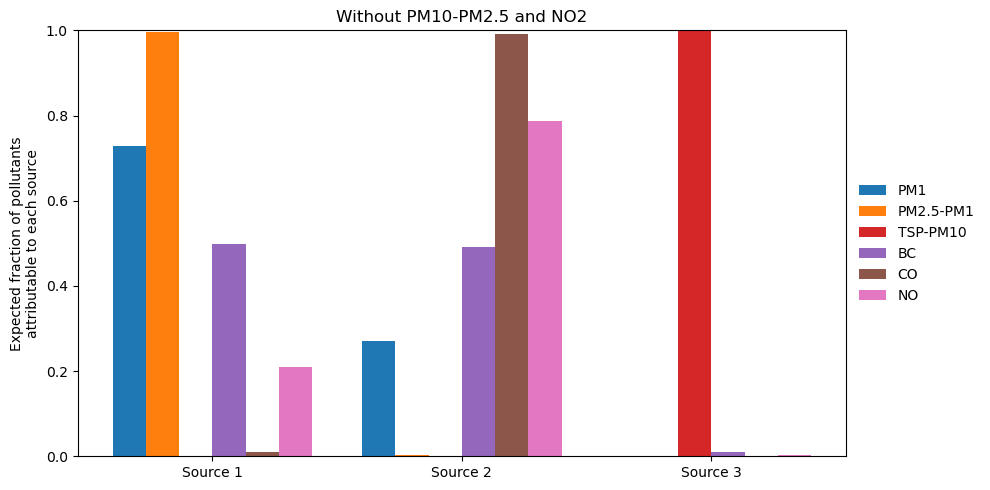

In [ ]:
plot_C_matrix_grouped_by_k(results["C"], title="Without PM10-PM2.5 and NO2", 
                           col_label=col_label, 
                           colors=colors, 
                        #    savepath="results/CB/figure/CB_nonegpm25mpm1_nopm10mpm25no2_sourceXray_K3_Phi.pdf"
                        )